In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
df = pd.read_csv("DataSet.csv")
df.head()

,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,in_balanced_dataset
0,Marketing Intern,"US, NY, New York",Marketing,NaN,"<h3>We're Food52, and we've created a groundbr...","<p>Food52, a fast-growing, James Beard Award-w...",<ul>\r\n<li>Experience with content management...,NaN,f,t,f,Other,Internship,NaN,NaN,Marketing,f,f
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"<h3>90 Seconds, the worlds Cloud Video Product...",<p>Organised - Focused - Vibrant - Awesome!<br...,<p><b>What we expect from you:</b></p>\r\n<p>Y...,<h3><b>What you will get from us</b></h3>\r\n<...,f,t,f,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,f,f
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,<h3></h3>\r\n<p>Valor Services provides Workfo...,"<p>Our client, located in Houston, is actively...",<ul>\r\n<li>Implement pre-commissioning and co...,NaN,f,t,f,NaN,NaN,NaN,NaN,NaN,f,f
3,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,<p>Our passion for improving quality of life t...,<p><b>THE COMPANY: ESRI – Environmental System...,<ul>\r\n<li>\r\n<b>EDUCATION: </b>Bachelor’s o...,<p>Our culture is anything but corporate—we ha...,f,t,f,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,f,f
4,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,<p>SpotSource Solutions LLC is a Global Human ...,<p><b>JOB TITLE:</b> Itemization Review Manage...,<p><b>QUALIFICATIONS:</b></p>\r\n<ul>\r\n<li>R...,<p>Full Benefits Offered</p>,f,t,t,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,f,f


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   title                17880 non-null  object
 1   location             17534 non-null  object
 2   department           6333 non-null   object
 3   salary_range         2868 non-null   object
 4   company_profile      14572 non-null  object
 5   description          17880 non-null  object
 6   requirements         15191 non-null  object
 7   benefits             10684 non-null  object
 8   telecommuting        17880 non-null  object
 9   has_company_logo     17880 non-null  object
 10  has_questions        17880 non-null  object
 11  employment_type      14409 non-null  object
 12  required_experience  10830 non-null  object
 13  required_education   9775 non-null   object
 14  industry             12977 non-null  object
 15  function             11425 non-null  object
 16  frau

In [13]:
df = df[['telecommuting',
         'has_company_logo',
         'has_questions',
         'employment_type',
         'required_experience',
         'fraudulent']]

df.head()

,telecommuting,has_company_logo,has_questions,employment_type,required_experience,fraudulent
0,f,t,f,Other,Internship,f
1,f,t,f,Full-time,Not Applicable,f
2,f,t,f,NaN,NaN,f
3,f,t,f,Full-time,Mid-Senior level,f
4,f,t,t,Full-time,Mid-Senior level,f


In [14]:
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10597 entries, 0 to 17879
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   telecommuting        10597 non-null  object
 1   has_company_logo     10597 non-null  object
 2   has_questions        10597 non-null  object
 3   employment_type      10597 non-null  object
 4   required_experience  10597 non-null  object
 5   fraudulent           10597 non-null  object
dtypes: object(6)
memory usage: 579.5+ KB


In [15]:
df['telecommuting'] = df['telecommuting'].map({'f':0, 't':1})
df['has_company_logo'] = df['has_company_logo'].map({'f':0, 't':1})
df['has_questions'] = df['has_questions'].map({'f':0, 't':1})
df['fraudulent'] = df['fraudulent'].map({'f':0, 't':1})

df.head()

,telecommuting,has_company_logo,has_questions,employment_type,required_experience,fraudulent
0,0,1,0,Other,Internship,0
1,0,1,0,Full-time,Not Applicable,0
3,0,1,0,Full-time,Mid-Senior level,0
4,0,1,1,Full-time,Mid-Senior level,0
6,0,1,1,Full-time,Mid-Senior level,0


In [16]:
from sklearn.preprocessing import LabelEncoder

le1 = LabelEncoder()
le2 = LabelEncoder()

df['employment_type'] = le1.fit_transform(df['employment_type'])
df['required_experience'] = le2.fit_transform(df['required_experience'])

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10597 entries, 0 to 17879
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   telecommuting        10597 non-null  int64
 1   has_company_logo     10597 non-null  int64
 2   has_questions        10597 non-null  int64
 3   employment_type      10597 non-null  int64
 4   required_experience  10597 non-null  int64
 5   fraudulent           10597 non-null  int64
dtypes: int64(6)
memory usage: 579.5 KB


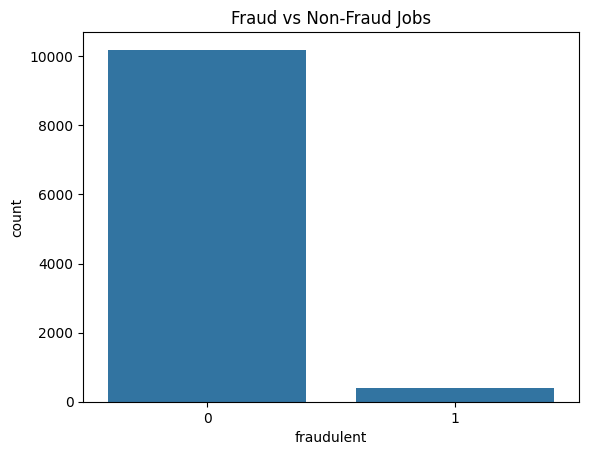

In [17]:
sns.countplot(x='fraudulent', data=df)
plt.title("Fraud vs Non-Fraud Jobs")
plt.show()

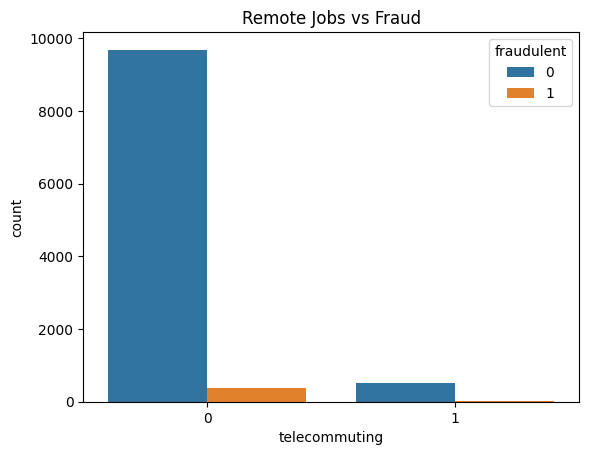

In [18]:
sns.countplot(x='telecommuting', hue='fraudulent', data=df)
plt.title("Remote Jobs vs Fraud")
plt.show()

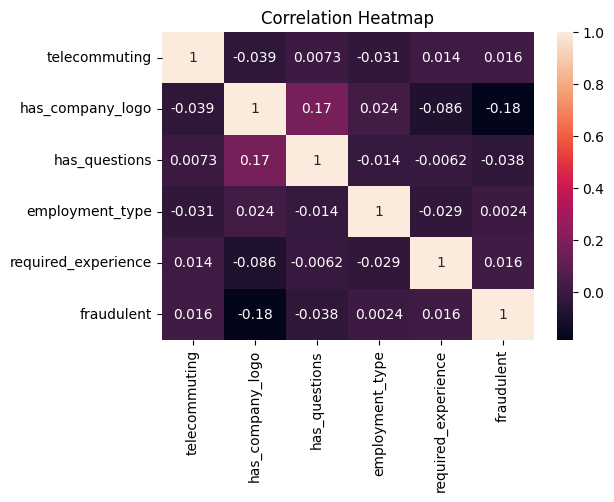

In [19]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Create model with class balancing
model = LogisticRegression(class_weight='balanced')

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Results
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.85      0.91      2034
           1       0.14      0.55      0.22        86

    accuracy                           0.84      2120
   macro avg       0.56      0.70      0.57      2120
weighted avg       0.94      0.84      0.88      2120

Confusion Matrix:

[[1737  297]
 [  39   47]]


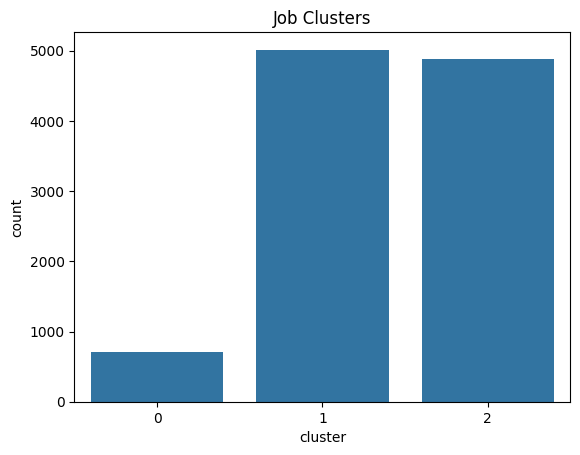

In [21]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

sns.countplot(x='cluster', data=df)
plt.title("Job Clusters")
plt.show()

In [27]:
df.groupby('cluster')['fraudulent'].mean()

,fraudulent
cluster,
0,0.039773
1,0.036099
2,0.041197


In [25]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))

In [36]:
import pickle

# Save trained model
pickle.dump(model, open("fraud_model.pkl", "wb"))

In [37]:
from google.colab import files
files.download("fraud_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
loaded_model = pickle.load(open("fraud_model.pkl", "rb"))